In [5]:
import numpy as np
import pandas as pd

# --- Constants ---
# Speed of light in m/s
c = 3.0e8
# Telescope diameter in meters
D = 12.0
# Given gain, not used for sigma calculation but kept for context
G0 = 0.035  # K/Jy
# Beam separation in degrees
beam_sep_deg = 0.9
# Convert separation to arcminutes for consistency
beam_sep_arcmin = beam_sep_deg * 60

# --- Frequency Array ---
# Frequencies in Hz
nu_array = np.array([
    1.152e+09, 1.173e+09, 1.194e+09, 1.215e+09, 1.236e+09, 1.257e+09,
    1.278e+09, 1.299e+09, 1.320e+09, 1.341e+09, 1.362e+09, 1.383e+09,
    1.404e+09, 1.425e+09, 1.446e+09, 1.467e+09, 1.488e+09
])

# --- Calculation ---
# Calculate sigma for each frequency in the nu_array in radians
sigma_rad_array = 1.22 * c / (2.355 * nu_array * D)

# Convert sigma from radians to arcminutes
# (1 radian = 180/pi degrees, 1 degree = 60 arcminutes)
sigma_arcmin_array = sigma_rad_array * (180 / np.pi) * 60

# Assuming a circular beam, sigma_x and sigma_y are the same
sigma_x_arcmin = sigma_arcmin_array
sigma_y_arcmin = sigma_arcmin_array

# --- Create and Save CSV ---
# Create a pandas DataFrame to hold the data
beam_df = pd.DataFrame({
    'frequency_hz': nu_array,
    'sigma_x_arcmin': sigma_x_arcmin,
    'sigma_y_arcmin': sigma_y_arcmin,
    'beam_sep_arcmin': beam_sep_arcmin
})

# Save the DataFrame to a CSV file
output_filename = 'ASKAP_beam_parameters.csv'
beam_df.to_csv(output_filename, index=False)

# --- Verification ---
# Print the DataFrame to the console to show the result
print(f"Successfully created '{output_filename}' with the following data:")
print(beam_df)

Successfully created 'ASKAP_beam_parameters.csv' with the following data:
    frequency_hz  sigma_x_arcmin  sigma_y_arcmin  beam_sep_arcmin
0   1.152000e+09       38.648294       38.648294             54.0
1   1.173000e+09       37.956381       37.956381             54.0
2   1.194000e+09       37.288807       37.288807             54.0
3   1.215000e+09       36.644309       36.644309             54.0
4   1.236000e+09       36.021711       36.021711             54.0
5   1.257000e+09       35.419916       35.419916             54.0
6   1.278000e+09       34.837899       34.837899             54.0
7   1.299000e+09       34.274700       34.274700             54.0
8   1.320000e+09       33.729420       33.729420             54.0
9   1.341000e+09       33.201219       33.201219             54.0
10  1.362000e+09       32.689306       32.689306             54.0
11  1.383000e+09       32.192939       32.192939             54.0
12  1.404000e+09       31.711421       31.711421             54.0
13

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Loaded beam parameters from 'ASKAP_beam_parameters.csv'
Using fixed beam separation: 54.0 arcmin (3240 arcsec)


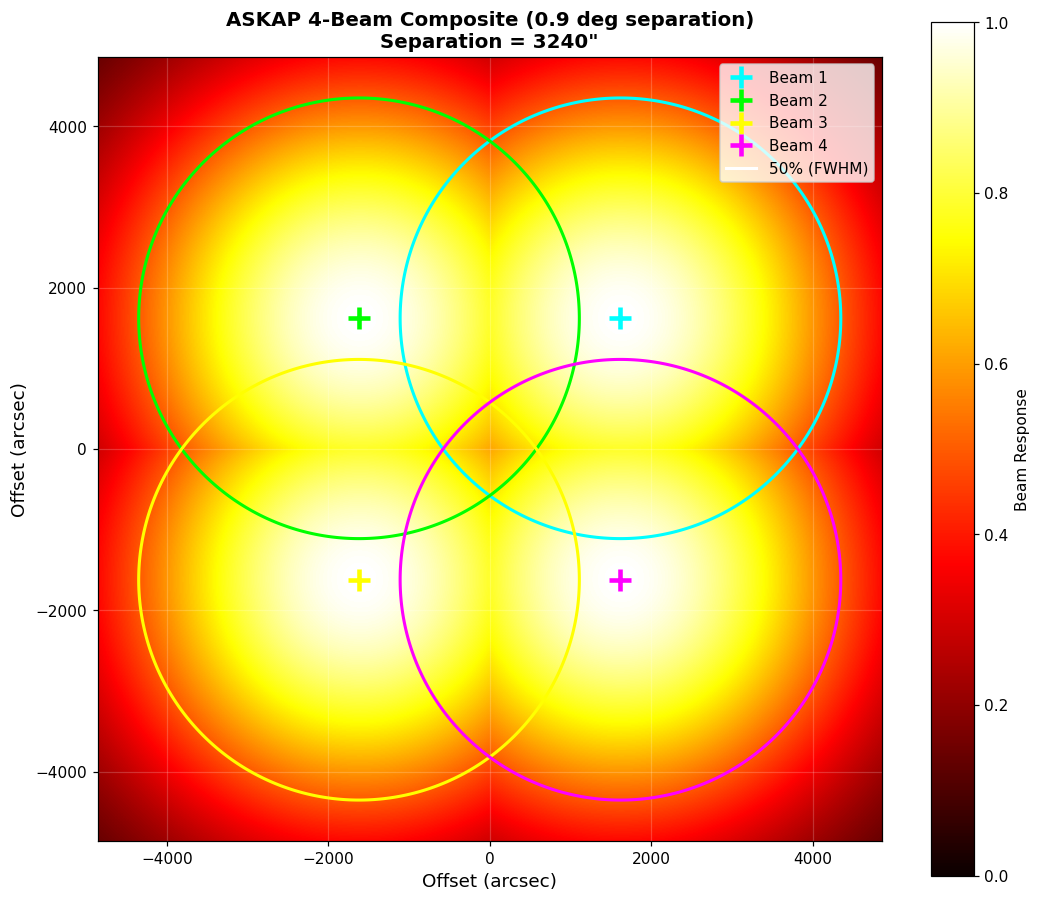

In [13]:

def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, amp=1.0):
    """2D Gaussian beam centered at (x0, y0)"""
    return amp * np.exp(-0.5 * (((x - x0) / sigma_x)**2 + ((y - y0) / sigma_y)**2))

# === BEAM PARAMETERS (from CSV file) ===
# Load the CSV and get parameters from the first row
try:
    beam_params_df = pd.read_csv('ASKAP_beam_parameters.csv')
    first_row = beam_params_df.iloc[0]
    # Convert from arcmin to arcsec for consistency with plotting units
    sigma_h = first_row['sigma_x_arcmin'] * 60
    sigma_v = first_row['sigma_y_arcmin'] * 60
    # Use the fixed beam separation from the CSV file (0.9 deg = 54 arcmin)
    beam_separation = first_row['beam_sep_arcmin'] * 60
    print("Loaded beam parameters from 'ASKAP_beam_parameters.csv'")
    print(f"Using fixed beam separation: {beam_separation/60:.1f} arcmin ({beam_separation:.0f} arcsec)")
except FileNotFoundError:
    print("Warning: 'ASKAP_beam_parameters.csv' not found. Using estimated values.")
    # Fallback values if the CSV doesn't exist
    sigma_h = 44.5 * 60
    sigma_v = 44.5 * 60
    beam_separation = 54 * 60 # 0.9 deg in arcsec

# --- Grid Setup ---
grid_extent = beam_separation * 1.5
grid_resolution = 500
x = np.linspace(-grid_extent, grid_extent, grid_resolution)
y = np.linspace(-grid_extent, grid_extent, grid_resolution)
X, Y = np.meshgrid(x, y)

# --- Define Beam Centers for a Square Pattern ---
half_sep = beam_separation / 2.0
centers = {
    'top_right':    ( half_sep,  half_sep),
    'top_left':     (-half_sep,  half_sep),
    'bottom_left':  (-half_sep, -half_sep),
    'bottom_right': ( half_sep, -half_sep)
}

# --- Calculate Individual and Composite Beams ---
individual_beams = {}
composite_beam = np.zeros_like(X)

for name, (x0, y0) in centers.items():
    beam = gaussian_2d(X, Y, x0, y0, sigma_h, sigma_v)
    individual_beams[name] = beam
    composite_beam = np.maximum(composite_beam, beam)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(10, 10), dpi=110)

# Plot composite beam heatmap
im = ax.imshow(composite_beam, extent=[-grid_extent, grid_extent, -grid_extent, grid_extent],
               origin='lower', cmap='hot', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Beam Response', shrink=0.8)

# Plot contours and markers for each beam
colors = {'top_right': 'cyan', 'top_left': 'lime', 'bottom_left': 'yellow', 'bottom_right': 'magenta'}
for name, (x0, y0) in centers.items():
    # FWHM contour (50%)
    ax.contour(X, Y, individual_beams[name], levels=[0.5], colors=[colors[name]], linestyles='-', linewidths=2)
    # Mark beam center
    ax.plot(x0, y0, '+', color=colors[name], markersize=15, markeredgewidth=3, label=f'Beam {list(centers.keys()).index(name)+1}')

# Add legend for contour levels
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='white', linestyle='-', linewidth=2, label='50% (FWHM)')
]

# Add labels and title
ax.set_xlabel('Offset (arcsec)', fontsize=12)
ax.set_ylabel('Offset (arcsec)', fontsize=12)
ax.set_title(f'ASKAP 4-Beam Composite (0.9 deg separation)\n'
             f'Separation = {beam_separation:.0f}"',
             fontsize=13, fontweight='bold')

handles, labels_leg = ax.get_legend_handles_labels()
handles.extend(legend_elements)
ax.legend(handles=handles, loc='upper right', fontsize=10)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2, color='white')

plt.tight_layout()
plt.show()
